In [1]:
from tensorflow.keras.datasets import fashion_mnist

In [2]:
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
train_images[1].shape

(28, 28)

In [4]:
train_labels[1]

np.uint8(0)

In [5]:
train_images.max(), train_images.min()

(np.uint8(255), np.uint8(0))

In [6]:
train_images.shape

(60000, 28, 28)

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

In [8]:
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

In [9]:
# Reshape our data => single channel (grayscale)

x_train = train_images.reshape(train_images.shape[0], 28, 28, 1)
x_test = test_images.reshape(test_images.shape[0], 28, 28, 1)

In [10]:
x_train[1].shape

(28, 28, 1)

In [11]:
np.unique(train_labels)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [12]:
# labels => OHE

num_classes = 10
y_train = to_categorical(train_labels, num_classes)
y_test = to_categorical(test_labels, num_classes)

In [13]:
y_train[1]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [14]:
# CNN Archi

model = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu',
           input_shape=(28,28,1)),

    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, kernel_size=(3,3), activation='relu'),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,506 (541.04 KB)

 Trainable params: 138,506 (541.04 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:

# compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [17]:
history = model.fit(x_train, y_train, epochs=12,
                    validation_data=(x_test, y_test))

Epoch 1/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.7314 - loss: 0.7202 - val_accuracy: 0.8651 - val_loss: 0.3680
Epoch 2/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8799 - loss: 0.3302 - val_accuracy: 0.8872 - val_loss: 0.3188
Epoch 3/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8987 - loss: 0.2757 - val_accuracy: 0.8901 - val_loss: 0.2937
Epoch 4/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9108 - loss: 0.2443 - val_accuracy: 0.8979 - val_loss: 0.2767
Epoch 5/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9204 - loss: 0.2163 - val_accuracy: 0.9087 - val_loss: 0.2558
Epoch 6/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9293 - loss: 0.1907 - val_accuracy: 0.9020 - val_loss: 0.2712
Epoch 7/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9354 - loss: 0.1758 - val_accuracy: 0.9117 - val_loss: 0.2590
Epoch 8/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9401 - loss: 0.1608

In [ ]:
# prediction

In [18]:
from PIL import Image
img = Image.open("/content/coat.jpg")

In [19]:
img = img.convert("L") # for gray scale

In [20]:
img = img.resize((28,28))

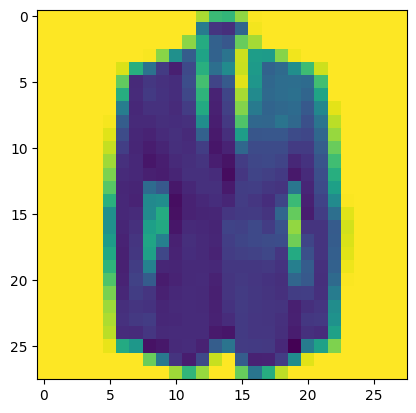

In [30]:
plt.imshow(img)

In [21]:
img_arr = np.array(img)

In [22]:
img_arr.max()

np.uint8(255)

In [23]:
img_arr = img_arr / 255.0

In [24]:
img_arr = img_arr.reshape(1, 28, 28, 1)

In [25]:
img_arr.shape

(1, 28, 28, 1)

In [26]:
prediction = model.predict(img_arr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step


In [27]:
prediction

array([[2.0807376e-03, 2.5293239e-05, 5.4160103e-02, 3.3446209e-04,
        7.7799363e-05, 2.7902949e-10, 9.4307798e-01, 8.5795711e-12,
        2.4357822e-04, 5.3231297e-10]], dtype=float32)

In [28]:
pred = np.argmax(prediction)

In [29]:
pred

np.int64(6)